In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [2]:
np.random.seed(42)

n = 500

data = {
    "Employee_ID": range(1, n+1),

    "Age": np.random.randint(22, 60, n),

    "Experience": np.random.randint(1, 20, n),

    "Department": np.random.choice(
        ["HR", "IT", "Finance", "Sales"],
        n
    ),

    "Salary": np.random.randint(25000, 120000, n),

    "Training_Hours": np.random.randint(5, 100, n),

    "Attendance": np.random.randint(60, 100, n),

    "Projects_Completed": np.random.randint(1, 15, n),

    "Performance_Score": np.random.randint(40, 100, n)
}

df = pd.DataFrame(data)

df.head()

,Employee_ID,Age,Experience,Department,Salary,Training_Hours,Attendance,Projects_Completed,Performance_Score
0,1,50,2,Finance,32906,94,91,11,44
1,2,36,5,Finance,86413,66,60,11,56
2,3,29,5,IT,79028,96,82,7,76
3,4,42,6,IT,32287,70,96,11,75
4,5,40,19,IT,58660,68,67,11,93


In [3]:
conditions = [
    df["Performance_Score"] >= 80,
    (df["Performance_Score"] >= 60) & (df["Performance_Score"] < 80),
    df["Performance_Score"] < 60
]

choices = [
    "High",
    "Medium",
    "Low"
]

df["Performance_Level"] = np.select(
    conditions,
    choices,
    default="Medium"
)

df.head()

,Employee_ID,Age,Experience,Department,Salary,Training_Hours,Attendance,Projects_Completed,Performance_Score,Performance_Level
0,1,50,2,Finance,32906,94,91,11,44,Low
1,2,36,5,Finance,86413,66,60,11,56,Low
2,3,29,5,IT,79028,96,82,7,76,Medium
3,4,42,6,IT,32287,70,96,11,75,Medium
4,5,40,19,IT,58660,68,67,11,93,High


In [4]:
df.to_csv("employee_data.csv", index=False)

print("Dataset Saved Successfully")

Dataset Saved Successfully


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Employee_ID         500 non-null    int64 
 1   Age                 500 non-null    int64 
 2   Experience          500 non-null    int64 
 3   Department          500 non-null    object
 4   Salary              500 non-null    int64 
 5   Training_Hours      500 non-null    int64 
 6   Attendance          500 non-null    int64 
 7   Projects_Completed  500 non-null    int64 
 8   Performance_Score   500 non-null    int64 
 9   Performance_Level   500 non-null    object
dtypes: int64(8), object(2)
memory usage: 39.2+ KB


In [6]:
df.head(10)

,Employee_ID,Age,Experience,Department,Salary,Training_Hours,Attendance,Projects_Completed,Performance_Score,Performance_Level
0,1,50,2,Finance,32906,94,91,11,44,Low
1,2,36,5,Finance,86413,66,60,11,56,Low
2,3,29,5,IT,79028,96,82,7,76,Medium
3,4,42,6,IT,32287,70,96,11,75,Medium
4,5,40,19,IT,58660,68,67,11,93,High
5,6,44,8,Sales,100758,74,72,2,58,Low
6,7,32,16,HR,85504,67,67,8,66,Medium
7,8,32,13,IT,84720,77,82,14,92,High
8,9,45,1,IT,59701,37,60,6,73,Medium
9,10,57,17,IT,108300,45,83,14,50,Low


In [7]:
df.describe()

,Employee_ID,Age,Experience,Salary,Training_Hours,Attendance,Projects_Completed,Performance_Score
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,250.500000,41.322000,9.822000,72234.030000,50.448000,79.690000,7.610000,69.504000
std,144.481833,11.051633,5.615816,27090.872856,27.652208,11.339271,4.146841,17.043913
min,1.000000,22.000000,1.000000,25281.000000,5.000000,60.000000,1.000000,40.000000
25%,125.750000,32.000000,5.000000,50807.500000,25.000000,70.000000,4.000000,55.000000
50%,250.500000,43.000000,10.000000,71354.500000,49.000000,80.000000,8.000000,70.000000
75%,375.250000,51.000000,15.000000,96668.750000,75.000000,89.000000,11.000000,84.000000
max,500.000000,59.000000,19.000000,119795.000000,99.000000,99.000000,14.000000,99.000000


In [8]:
df.isnull().sum()

,0
Employee_ID,0
Age,0
Experience,0
Department,0
Salary,0
Training_Hours,0
Attendance,0
Projects_Completed,0
Performance_Score,0
Performance_Level,0


In [9]:
df.duplicated().sum()

np.int64(0)

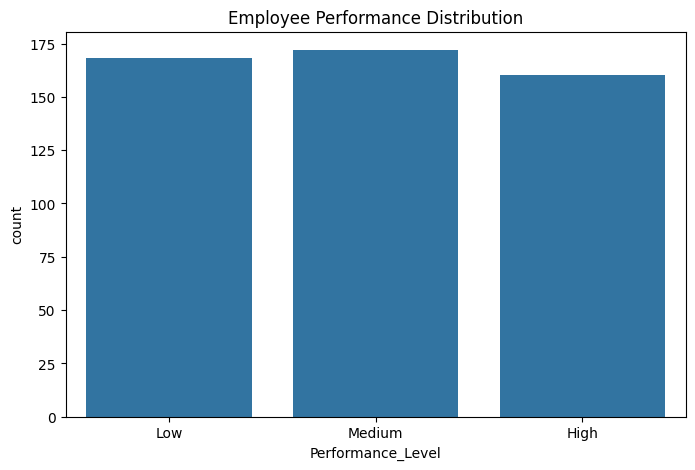

In [10]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="Performance_Level",
    data=df
)

plt.title("Employee Performance Distribution")

plt.show()

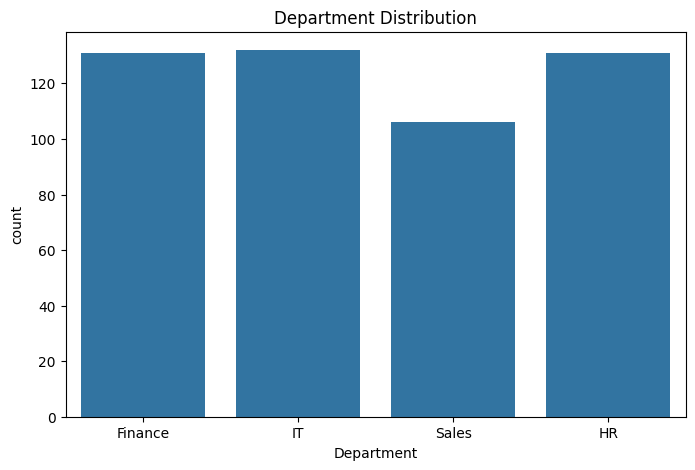

In [11]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="Department",
    data=df
)

plt.title("Department Distribution")

plt.show()

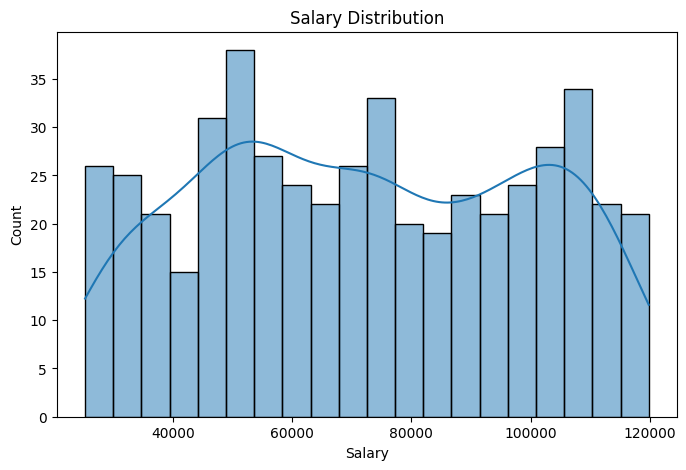

In [12]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Salary"],
    bins=20,
    kde=True
)

plt.title("Salary Distribution")

plt.show()

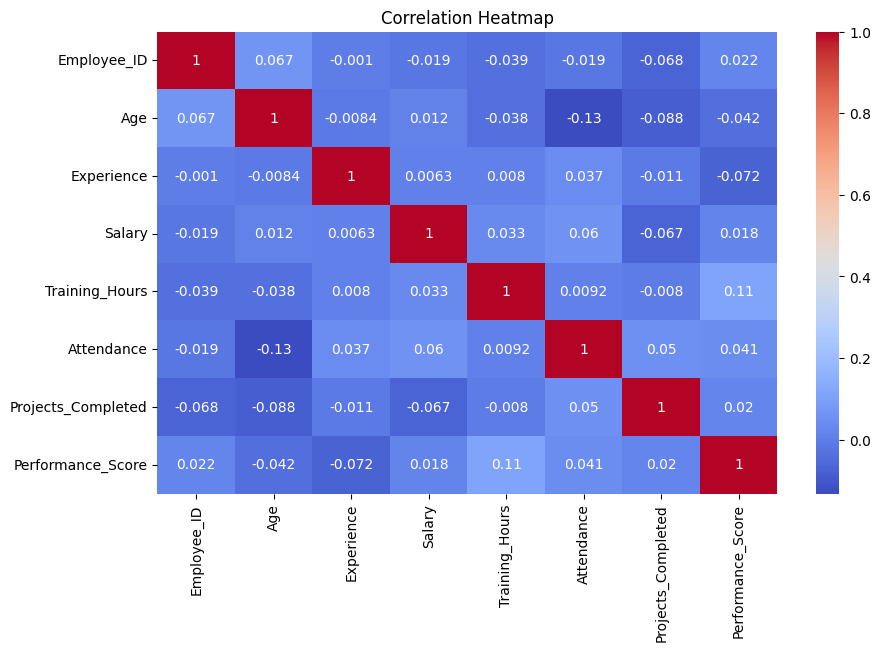

In [13]:
plt.figure(figsize=(10,6))

numeric_df = df.select_dtypes(include=np.number)

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

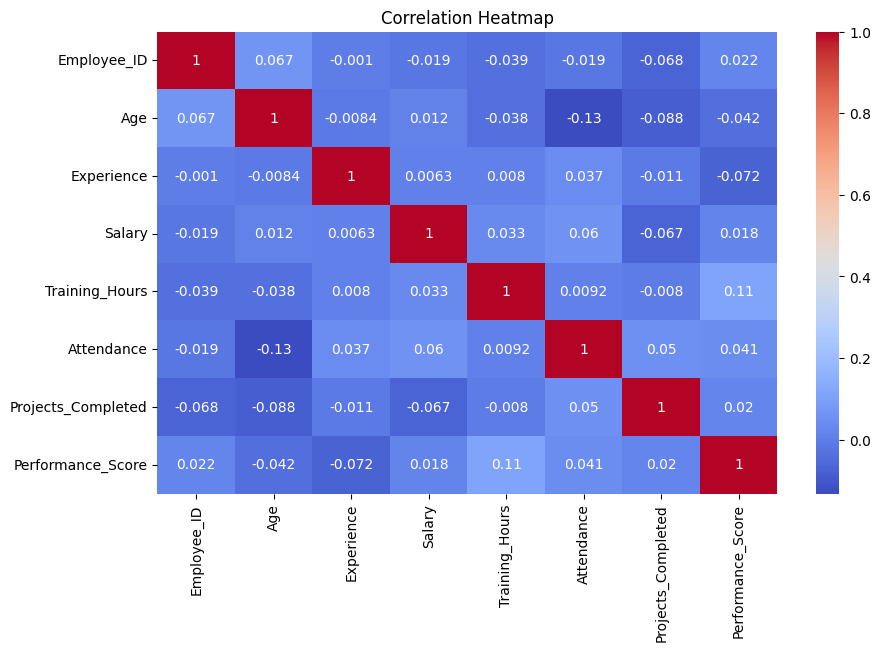

In [16]:
plt.figure(figsize=(10,6))

numeric_df = df.select_dtypes(include=np.number)

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.savefig(
    "correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [17]:
from sklearn.preprocessing import LabelEncoder

le_department = LabelEncoder()
le_performance = LabelEncoder()

df["Department"] = le_department.fit_transform(df["Department"])

df["Performance_Level"] = le_performance.fit_transform(
    df["Performance_Level"]
)

df.head()

,Employee_ID,Age,Experience,Department,Salary,Training_Hours,Attendance,Projects_Completed,Performance_Score,Performance_Level
0,1,50,2,0,32906,94,91,11,44,1
1,2,36,5,0,86413,66,60,11,56,1
2,3,29,5,2,79028,96,82,7,76,2
3,4,42,6,2,32287,70,96,11,75,2
4,5,40,19,2,58660,68,67,11,93,0


In [18]:
X = df.drop(
    ["Employee_ID", "Performance_Level"],
    axis=1
)

y = df["Performance_Level"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (400, 8)
Testing Data: (100, 8)


In [19]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("Model Trained Successfully")

Model Trained Successfully


In [20]:
y_pred = model.predict(X_test)

print(y_pred[:10])

[2 1 2 1 2 2 2 2 1 0]


In [21]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:", accuracy)

Accuracy: 1.0


In [22]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        29
           1       1.00      1.00      1.00        27
           2       1.00      1.00      1.00        44

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



In [23]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[29  0  0]
 [ 0 27  0]
 [ 0  0 44]]


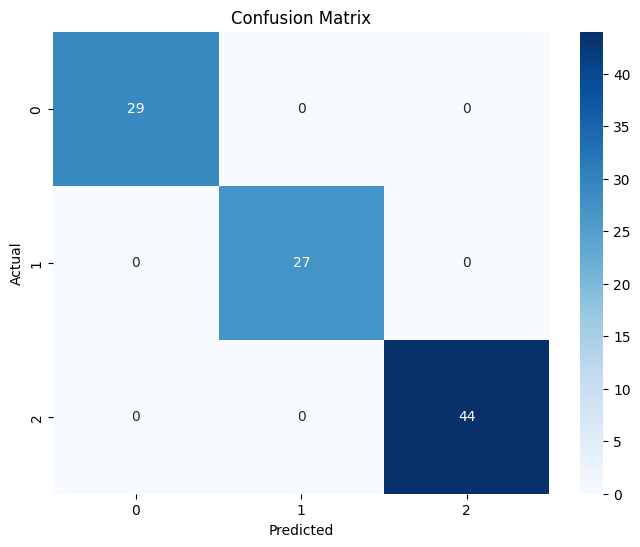

In [24]:
plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [25]:
importance = model.feature_importances_

features = X.columns

feature_df = pd.DataFrame({
    "Feature": features,
    "Importance": importance
})

feature_df = feature_df.sort_values(
    by="Importance",
    ascending=False
)

print(feature_df)

              Feature  Importance
7   Performance_Score    0.688803
3              Salary    0.059480
4      Training_Hours    0.054101
0                 Age    0.049439
5          Attendance    0.047178
6  Projects_Completed    0.040345
1          Experience    0.038058
2          Department    0.022597


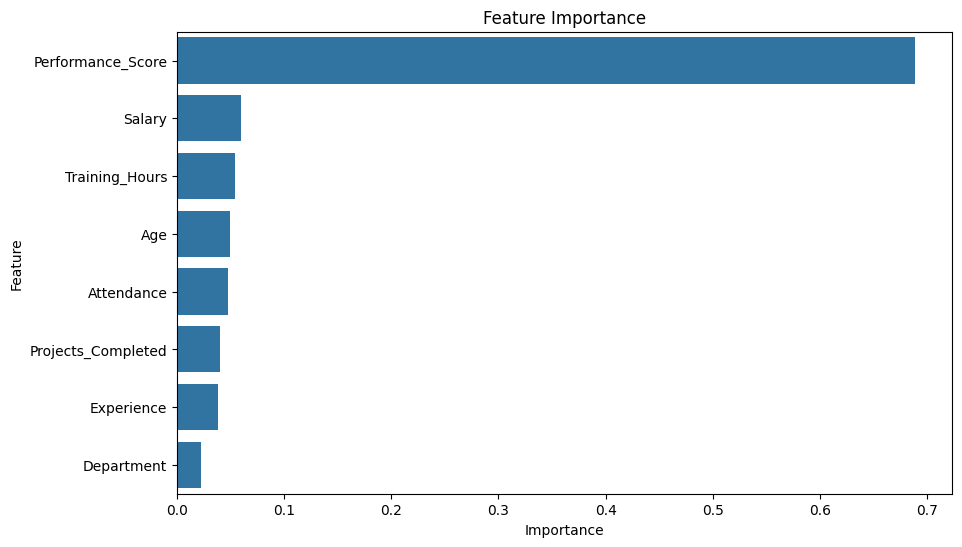

In [26]:
plt.figure(figsize=(10,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_df
)

plt.title(
    "Feature Importance"
)

plt.show()

In [27]:
import joblib

joblib.dump(
    model,
    "employee_performance_model.pkl"
)

print("Model Saved Successfully")

Model Saved Successfully


In [28]:
new_employee = pd.DataFrame({
    'Age':[30],
    'Experience':[5],
    'Department':[1],  # IT
    'Salary':[60000],
    'Training_Hours':[50],
    'Attendance':[95],
    'Projects_Completed':[8],
    'Performance_Score':[85]
})

prediction = model.predict(new_employee)

print("Prediction:", prediction)

Prediction: [0]


In [29]:
result = le_performance.inverse_transform(prediction)

print("Predicted Performance:", result[0])

Predicted Performance: High


In [30]:
prediction_df = new_employee.copy()

prediction_df["Predicted_Performance"] = result

prediction_df.to_csv(
    "employee_prediction.csv",
    index=False
)

print("Prediction File Saved")

Prediction File Saved


In [31]:
import joblib

joblib.dump(
    model,
    "employee_performance_model.pkl"
)

['employee_performance_model.pkl']

In [32]:
import os

print(os.listdir())

['.config', 'employee_data.csv', 'correlation_heatmap.png', 'employee_prediction.csv', 'employee_performance_model.pkl', 'sample_data']


In [34]:
from google.colab import files

files.download("employee_performance_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

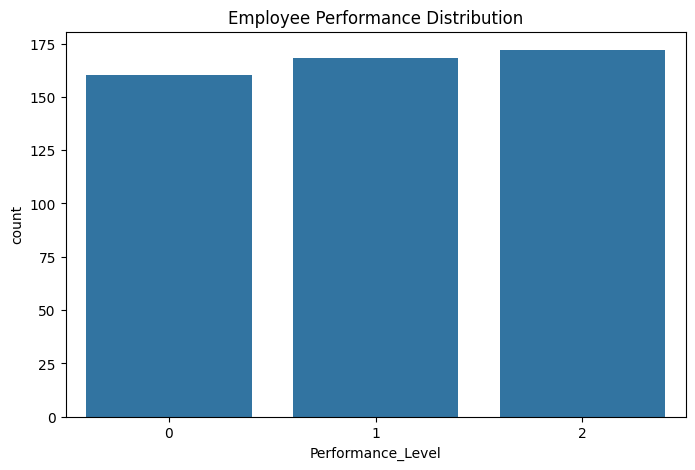

In [37]:
plt.figure(figsize=(8,5))

sns.countplot(x="Performance_Level", data=df)

plt.title("Employee Performance Distribution")

plt.savefig(
    "performance_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [38]:
from google.colab import files
files.download("performance_distribution.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

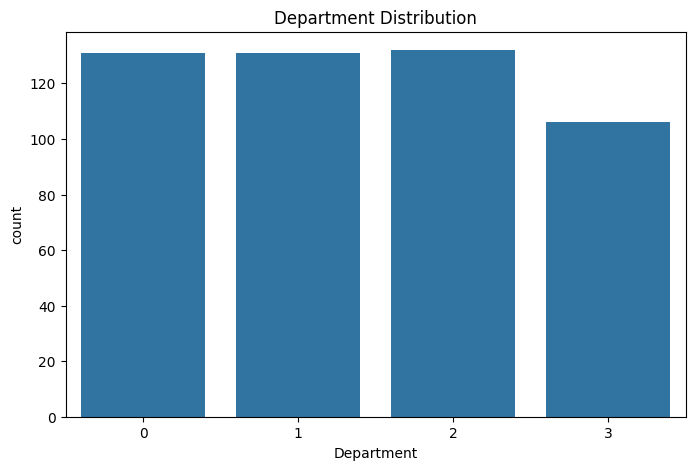

In [39]:
plt.figure(figsize=(8,5))

sns.countplot(x="Department", data=df)

plt.title("Department Distribution")

plt.savefig(
    "department_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [40]:
files.download("department_distribution.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

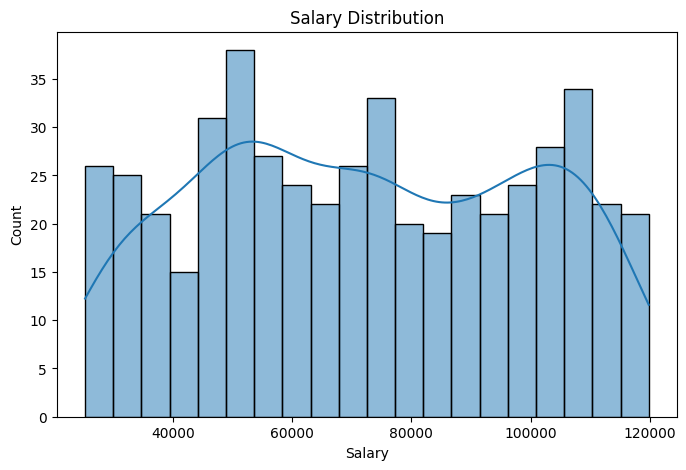

In [41]:
plt.figure(figsize=(8,5))

sns.histplot(df["Salary"], bins=20, kde=True)

plt.title("Salary Distribution")

plt.savefig(
    "salary_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [42]:
files.download("salary_distribution.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

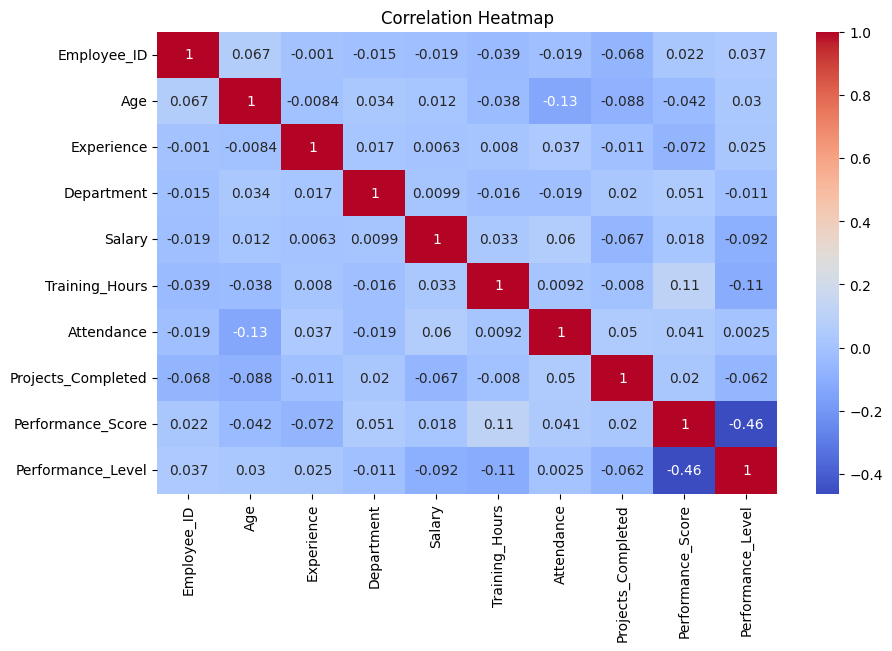

In [43]:
plt.figure(figsize=(10,6))

numeric_df = df.select_dtypes(include=np.number)

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.savefig(
    "correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [44]:
files.download("correlation_heatmap.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

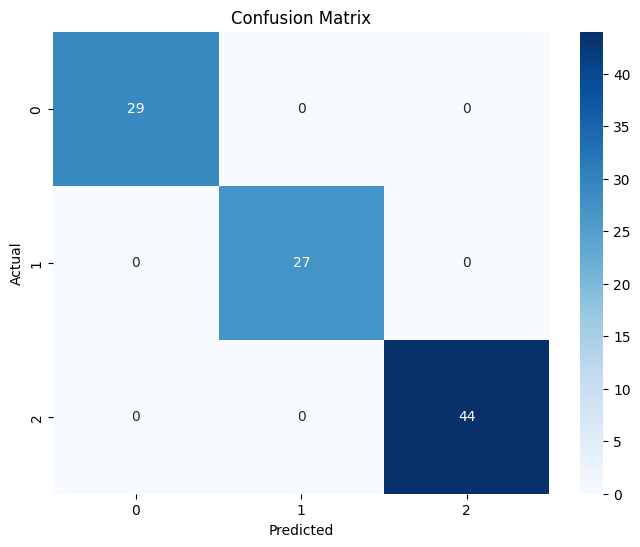

In [45]:
plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig(
    "confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [46]:
files.download("confusion_matrix.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

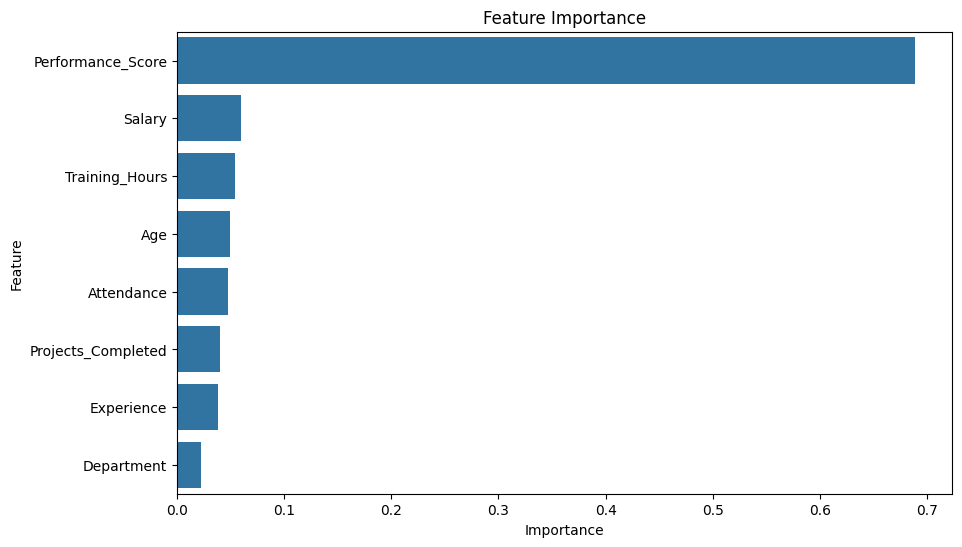

In [47]:
plt.figure(figsize=(10,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_df
)

plt.title("Feature Importance")

plt.savefig(
    "feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [48]:
files.download("feature_importance.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>